In [5]:
import os
import numpy as np
from PIL import Image

In [6]:
data = []
labels = []
classes = 43
cur_path = os.getcwd() 

print("Obtaining Images & its Labels..............")
for i in range(classes):
    path = os.path.join(cur_path, 'dataset/train/', str(i))
    images = os.listdir(path)
    for a in images:
        try:
            image = Image.open(os.path.join(path, a))
            image = image.resize((30, 30))
            image = np.array(image)
            data.append(image)
            labels.append(i)
        except Exception as e:
            print(f"Error loading image {a}: {e}")

Obtaining Images & its Labels..............


In [7]:
data = np.array(data)
labels = np.array(labels)

print(data.shape, labels.shape)

(38883, 30, 30, 3) (38883,)


In [8]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)

In [9]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu', input_shape=X_train.shape[1:]))
model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(43, activation='softmax'))

c:\Users\acer\Desktop\Data-Science-Portfolio\Road Sign Recognistion\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
history = model.fit(X_train, y_train, batch_size=32, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.4698 - loss: 2.0271 - val_accuracy: 0.8344 - val_loss: 0.6410
Epoch 2/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.7281 - loss: 0.9065 - val_accuracy: 0.9042 - val_loss: 0.3580
Epoch 3/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8024 - loss: 0.6459 - val_accuracy: 0.9397 - val_loss: 0.2086
Epoch 4/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8629 - loss: 0.4545 - val_accuracy: 0.9451 - val_loss: 0.1901
Epoch 5/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8969 - loss: 0.3451 - val_accuracy: 0.9654 - val_loss: 0.1231
Epoch 6/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9134 - loss: 0.2938 - val_accuracy: 0.9726 - val_loss: 0.0966
Epoch 7/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9234 - loss: 0.2603 - val_accuracy: 0.9744 - val_loss: 0.0935
Epoch 8/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9266 - loss: 0.2525 - 

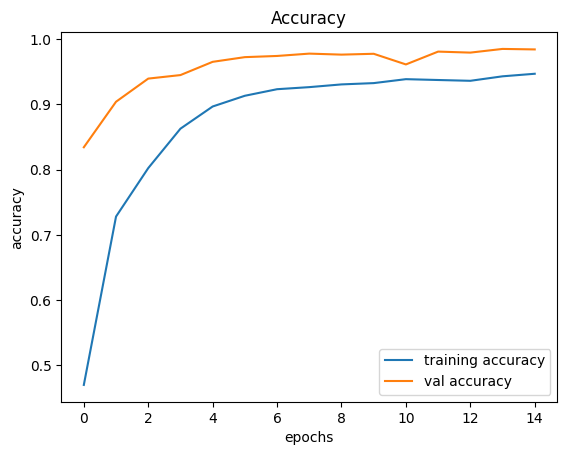

In [12]:
import matplotlib.pyplot as plt

plt.figure(0)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

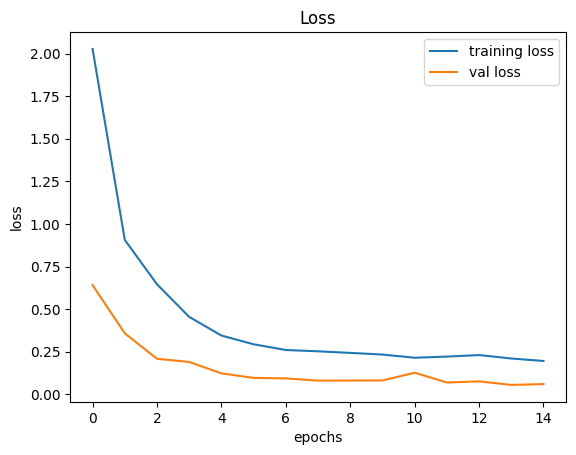

In [13]:
plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [14]:
model.save("my_model.h5")